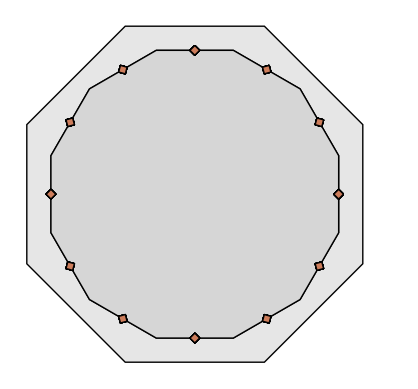

In [1]:
import veux
import xara
from xsection import CompositeSection
from xsection.library import Circle, Equigon
from xara_units.iks import inch, foot 

d = (11/8)*inch
ds = 4/8*inch # diameter of the shear spiral
cover = (3 + 1/8)*inch
core_radius = 5/2*foot - cover - ds - d/2
nr = 12

octagon  = Equigon(5*foot/2, z=0,
                    name="cover", divisions=8)

interior = Equigon(core_radius, z=1,
                    name="core", divisions=nr)

bar = Circle(d/2, z=2, mesh_scale=1/2, divisions=4, name="rebar")

xr = ((5*foot/2) - cover - ds - d/2, 0)


shape = CompositeSection([
            octagon,
            interior,
            *bar.linspace(xr, xr, nr, endpoint=False, center=(0,0))
        ])

veux.draw_shape(shape)

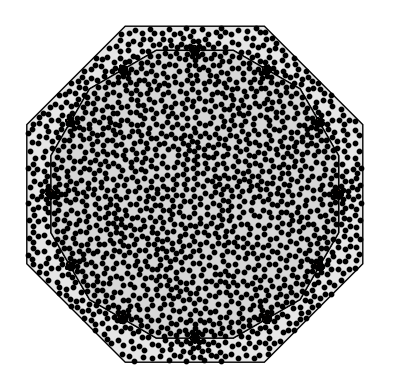

In [2]:
fiber_layout = {
    "core": {"n": 20, "rule": "sunflower"},
    "rebar": {"d": 1}
    
}
section = xara.FrameSection("UniaxialFiber", shape, fibers=fiber_layout)
veux.draw_shape(section)